In [1]:
import sys
sys.path.append("../src")

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from qiskit_bb84 import (
    create_bb84_circuit,
    run_single_bb84_circuit,
    run_all_bb84_basis_cases
)

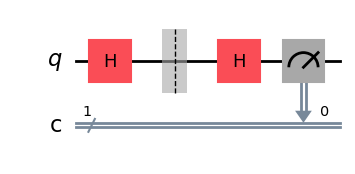

In [4]:
circuit = create_bb84_circuit(
    alice_bit=0,
    alice_basis="X",
    bob_basis="X"
)

circuit.draw("mpl")

In [5]:
same_basis_tests = [
    (0, "Z", "Z"),
    (1, "Z", "Z"),
    (0, "X", "X"),
    (1, "X", "X"),
]

for alice_bit, alice_basis, bob_basis in same_basis_tests:
    result = run_single_bb84_circuit(
        alice_bit=alice_bit,
        alice_basis=alice_basis,
        bob_basis=bob_basis,
        shots=1000
    )

    print(
        f"Alice bit={alice_bit}, Alice basis={alice_basis}, Bob basis={bob_basis}, "
        f"Counts={result["counts"]}"
    )

Alice bit=0, Alice basis=Z, Bob basis=Z, Counts={'0': 1000}
Alice bit=1, Alice basis=Z, Bob basis=Z, Counts={'1': 1000}
Alice bit=0, Alice basis=X, Bob basis=X, Counts={'0': 1000}
Alice bit=1, Alice basis=X, Bob basis=X, Counts={'1': 1000}


In [6]:
different_basis_tests = [
    (0, "Z", "X"),
    (1, "Z", "X"),
    (0, "X", "Z"),
    (1, "X", "Z"),
]

for alice_bit, alice_basis, bob_basis in different_basis_tests:
    result = run_single_bb84_circuit(
        alice_bit=alice_bit,
        alice_basis=alice_basis,
        bob_basis=bob_basis,
        shots=1000
    )

    print(
        f"Alice bit={alice_bit}, Alice basis={alice_basis}, Bob basis={bob_basis}, "
        f"Counts={result['counts']}"
    )

Alice bit=0, Alice basis=Z, Bob basis=X, Counts={'1': 495, '0': 505}
Alice bit=1, Alice basis=Z, Bob basis=X, Counts={'0': 498, '1': 502}
Alice bit=0, Alice basis=X, Bob basis=Z, Counts={'0': 502, '1': 498}
Alice bit=1, Alice basis=X, Bob basis=Z, Counts={'1': 491, '0': 509}


In [7]:
results = run_all_bb84_basis_cases(shots=1000)

rows = []

for result in results:
    counts = result["counts"]
    zeros = counts.get("0", 0)
    ones = counts.get("1", 0)

    rows.append({
        "alice_bit": result["alice_bit"],
        "alice_basis": result["alice_basis"],
        "bob_basis": result["bob_basis"],
        "shots": result["shots"],
        "count_0": zeros,
        "count_1": ones,
        "prob_0": zeros / result["shots"],
        "prob_1": ones / result["shots"],
        "same_basis": result["alice_basis"] == result["bob_basis"]
    })

df = pd.DataFrame(rows)
df

,alice_bit,alice_basis,bob_basis,shots,count_0,count_1,prob_0,prob_1,same_basis
0,0,Z,Z,1000,1000,0,1.000,0.000,True
1,0,Z,X,1000,478,522,0.478,0.522,False
2,0,X,Z,1000,455,545,0.455,0.545,False
3,0,X,X,1000,1000,0,1.000,0.000,True
4,1,Z,Z,1000,0,1000,0.000,1.000,True
5,1,Z,X,1000,506,494,0.506,0.494,False
6,1,X,Z,1000,501,499,0.501,0.499,False
7,1,X,X,1000,0,1000,0.000,1.000,True


In [8]:
df.to_csv("../results/qiskit_bb84_basis_results.csv", index=False)

print("Saved results to ../results/qiskit_bb84_basis_results.csv")

Saved results to ../results/qiskit_bb84_basis_results.csv


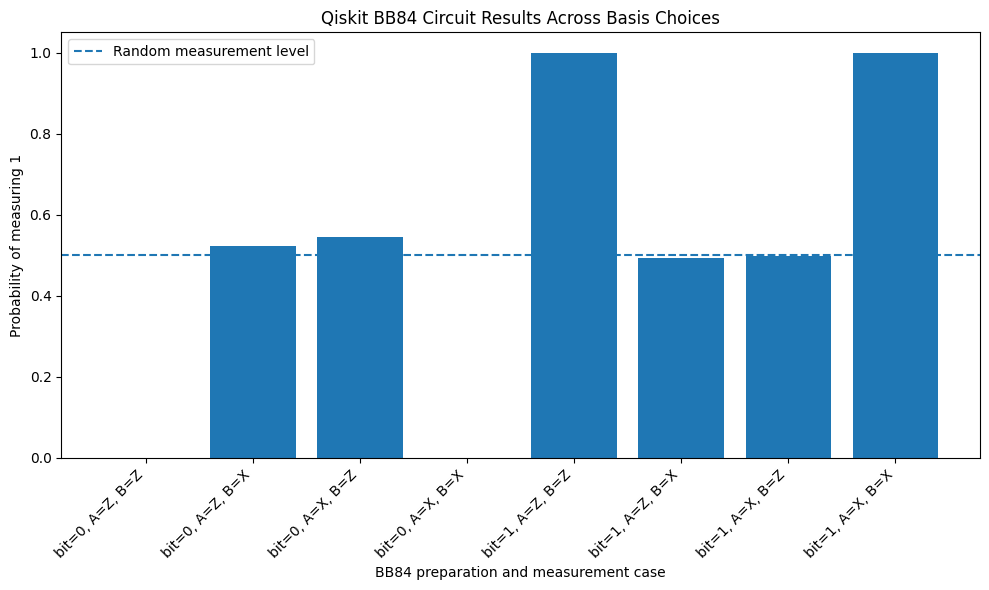

In [9]:
plot_df = df.copy()

plot_df["case"] = (
    "bit=" + plot_df["alice_bit"].astype(str)
    + ", A=" + plot_df["alice_basis"]
    + ", B=" + plot_df["bob_basis"]
)

plt.figure(figsize=(10, 6))
plt.bar(plot_df["case"], plot_df["prob_1"])

plt.axhline(0.5, linestyle="--", label="Random measurement level")

plt.xlabel("BB84 preparation and measurement case")
plt.ylabel("Probability of measuring 1")
plt.title("Qiskit BB84 Circuit Results Across Basis Choices")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()

plt.savefig("../figures/qiskit_bb84_basis_results.png", dpi=300)
plt.show()

## Qiskit-Based BB84 Circuit Demonstration

This notebook connects the protocol-level BB84 simulator to actual quantum circuits.

Alice prepares one of four BB84 states:

- bit 0 in Z basis: |0>
- bit 1 in Z basis: |1>
- bit 0 in X basis: |+>
- bit 1 in X basis: |->

Bob then measures in either the Z basis or the X basis.

When Alice and Bob use the same basis, Bob's measurement result is deterministic and matches Alice's bit. When Alice and Bob use different bases, Bob's result becomes approximately random.

This circuit-level demonstration supports the simplified rule used in the protocol simulator:

- same basis → correct bit
- different basis → random bit